# Seq2Seq + Bidirectional LSTM + Additive Attention — Improved Version
## English → French Neural Machine Translation using Hugging Face OPUS Books

### Improvements in this version
- Padding-aware Embeddings (`mask_zero=True`) so LSTM/Attention can ignore padded tokens
- Lower AdamW learning rate + weight decay for better validation generalization
- Stronger dropout to reduce overfitting
- Gradient clipping and adaptive learning-rate reduction
- Early stopping based on validation loss
- Keras 3 / TensorFlow 2.21-safe inference attention (does not reuse the problematic built-in Attention call in the one-step graph)
- BLEU-4, token accuracy, confusion matrix and attention heatmap

> Validation accuracy is not guaranteed to reach a fixed number. For translation, BLEU and qualitative translations should also be considered alongside token accuracy.


In [1]:
# Install once if needed.
# Recommended packages:
# !pip install -U datasets huggingface_hub pyarrow tensorflow scikit-learn pandas numpy matplotlib seaborn nltk

import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# Main experiment parameters
# ---------------------------
MAX_SAMPLES = 100000
MAX_LEN = 40
VOCAB_SIZE = 20000

EMBED_DIM = 256
ENCODER_UNITS = 256
DECODER_UNITS = 512
DROPOUT_RATE = 0.30

BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 5e-4

MODEL_DIR = "models"
VIS_DIR = "visualization"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("TensorFlow on native Windows >= 2.11 normally does not use CUDA GPUs directly.")
print("For NVIDIA GPU training, consider WSL2/Linux or another supported TensorFlow GPU environment.")


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow on native Windows >= 2.11 normally does not use CUDA GPUs directly.
For NVIDIA GPU training, consider WSL2/Linux or another supported TensorFlow GPU environment.


## 1. Load OPUS Books English–French

In [2]:
OPUS_REPO = "Helsinki-NLP/opus_books"
OPUS_CONFIG = "en-fr"
OPUS_PARQUET_URL = (
    "https://huggingface.co/datasets/Helsinki-NLP/opus_books/"
    "resolve/main/en-fr/train-00000-of-00001.parquet"
)

try:
    books = load_dataset(OPUS_REPO, OPUS_CONFIG, revision="main")
except Exception as e:
    print("Standard Hugging Face loading failed:", type(e).__name__, str(e)[:300])
    print("Trying the official Parquet file...")
    books = load_dataset("parquet", data_files={"train": OPUS_PARQUET_URL})

print(books)
print("Available raw pairs:", len(books["train"]))
print(books["train"][0])


DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 127085
    })
})
Available raw pairs: 127085
{'id': '0', 'translation': {'en': 'The Wanderer', 'fr': 'Le grand Meaulnes'}}


In [3]:
raw_df = books["train"].to_pandas()

pairs = pd.DataFrame({
    "en": raw_df["translation"].apply(lambda x: x["en"]),
    "fr": raw_df["translation"].apply(lambda x: x["fr"])
})

print("Raw pairs:", len(pairs))
display(pairs.head())


Raw pairs: 127085


,en,fr
0,The Wanderer,Le grand Meaulnes
1,Alain-Fournier,Alain-Fournier
2,First Part,PREMIÈRE PARTIE
3,I,CHAPITRE PREMIER
4,THE BOARDER,LE PENSIONNAIRE


## 2. Clean data and select up to 100k usable pairs

The original notebook limited the experiment to 30,000 examples. Here the limit is increased to **100,000** after filtering.

The split is performed **after cleaning/filtering and before training**, so the test set remains held out.


In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(
        r"[^a-zàâçéèêëîïôûùüÿñæœ'!?.,;:()\-\s]",
        " ",
        text
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

pairs["en"] = pairs["en"].apply(clean_text)
pairs["fr"] = pairs["fr"].apply(clean_text)

pairs = pairs[
    (pairs["en"].str.len() > 0) &
    (pairs["fr"].str.len() > 0)
].copy()

pairs["en_words"] = pairs["en"].str.split().str.len()
pairs["fr_words"] = pairs["fr"].str.split().str.len()

# Keep examples that fit the sequence length.
pairs = pairs[
    (pairs["en_words"] <= MAX_LEN) &
    (pairs["fr_words"] <= MAX_LEN)
].copy()

pairs = pairs.drop_duplicates(subset=["en", "fr"]).reset_index(drop=True)

# Shuffle deterministically and take at most 100k.
pairs = pairs.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
pairs = pairs.iloc[:min(MAX_SAMPLES, len(pairs))].copy()

# Decoder targets.
pairs["fr_target"] = pairs["fr"].apply(
    lambda x: "[start] " + x + " [end]"
)

print("Usable pairs selected:", len(pairs))
display(pairs[["en", "fr", "fr_target"]].head())

Usable pairs selected: 100000


,en,fr,fr_target
0,is your secret of enough importance to me to s...,-- ton secret vaut-il la peine que je te garde...,[start] -- ton secret vaut-il la peine que je ...
1,our situation with regard to lady catherine's ...,nos rapports avec la famille de lady catherine...,[start] nos rapports avec la famille de lady c...
2,"her soul, tortured by pride, at length found r...","son âme, courbatue d orgueil, se reposait enfi...","[start] son âme, courbatue d orgueil, se repos..."
3,a sudden light burst in upon me; these hints a...,soudain une lueur se fit dans mon esprit; ces ...,[start] soudain une lueur se fit dans mon espr...
4,when will we reach vanikoro?,-- quand serons-nous à vanikoro ?,[start] -- quand serons-nous à vanikoro ? [end]


## 3. Train / validation / test split

In [5]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.20,
    random_state=SEED
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=SEED
)

print(f"Train:      {len(train_pairs):,}")
print(f"Validation: {len(val_pairs):,}")
print(f"Test:       {len(test_pairs):,}")


Train:      80,000
Validation: 10,000
Test:       10,000


## 4. Text Vectorization

In [6]:
def standardize_text(text):
    return tf.strings.lower(text)

source_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize=standardize_text,
)

target_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN + 1,
    standardize=standardize_text,
)

source_vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(train_pairs["en"].values).batch(512)
)

target_vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(train_pairs["fr_target"].values).batch(512)
)

source_vocab = source_vectorizer.get_vocabulary()
target_vocab = target_vectorizer.get_vocabulary()

source_vocab_size = len(source_vocab)
target_vocab_size = len(target_vocab)

source_word_to_id = {w: i for i, w in enumerate(source_vocab)}
target_word_to_id = {w: i for i, w in enumerate(target_vocab)}
target_id_to_word = {i: w for i, w in enumerate(target_vocab)}

START_ID = target_word_to_id.get("[start]")
END_ID = target_word_to_id.get("[end]")

print("Source vocabulary:", source_vocab_size)
print("Target vocabulary:", target_vocab_size)
print("[start] ID:", START_ID)
print("[end] ID:", END_ID)

I0000 00:00:1790349350.965835   29714 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790349350.968131   29714 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Source vocabulary: 20000
Target vocabulary: 20000
[start] ID: 2
[end] ID: 3


## 5. Build efficient `tf.data` pipelines

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def vectorize_batch(en_text, fr_text):
    encoder_tokens = source_vectorizer(en_text)
    target_tokens = target_vectorizer(fr_text)

    # Teacher forcing:
    # decoder input  = [start] ... token_(t-1)
    # decoder target = token_(t) ... [end]
    decoder_input = target_tokens[:, :-1]
    decoder_target = target_tokens[:, 1:]

    return {
        "source_tokens": encoder_tokens,
        "decoder_tokens": decoder_input
    }, decoder_target

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["en"].values, df["fr_target"].values)
    )
    if shuffle:
        ds = ds.shuffle(min(len(df), 20_000), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(vectorize_batch, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_pairs, shuffle=True)
val_ds = make_dataset(val_pairs)
test_ds = make_dataset(test_pairs)

sample_x, sample_y = next(iter(train_ds))
print("Encoder batch:", sample_x["source_tokens"].shape)
print("Decoder input batch:", sample_x["decoder_tokens"].shape)
print("Decoder target batch:", sample_y.shape)

Encoder batch: (32, 40)
Decoder input batch: (32, 40)
Decoder target batch: (32, 40)


## 6. Masked loss and masked token accuracy

Padding token ID is `0` in `TextVectorization`. Padding is excluded from both metrics.


In [8]:
LOSS_FN = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

def masked_loss(y_true, y_pred):
    loss = LOSS_FN(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, 0), loss.dtype)
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    pred_ids = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    matches = tf.cast(tf.equal(y_true, pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(matches * mask) / tf.reduce_sum(mask)

## 7. Bidirectional LSTM + Additive Attention model

### Architecture

```text
English tokens
      ↓
Embedding(256)
      ↓
Bidirectional LSTM(256)
      ↓
Encoder sequence + forward/backward states
      ↓
Projection to Decoder LSTM(512) states
      ↓
Decoder LSTM(512)
      ↓
Additive Attention
      ↓
Concatenate decoder output + context
      ↓
Dropout(0.30)
      ↓
Dense + Softmax
      ↓
French tokens
```


### Why the previous `BroadcastTo` error happened

The error was caused by Keras automatic mask propagation from `Embedding(mask_zero=True)` into the built-in `AdditiveAttention`. In the current Keras/TensorFlow stack, the mask could be broadcast with an invalid shape during `fit()`. This version disables automatic embedding masks and performs explicit encoder-padding masking inside the custom additive attention layer. The masked loss still excludes target padding from the training objective.

This also avoids the previous one-step inference shape error because training and inference use the same custom attention implementation.


In [9]:
# ============================================================
# 7. Bidirectional LSTM + Custom Additive Attention
# Keras 3 / TF 2.20+ safe
#
# IMPORTANT:
# We intentionally use mask_zero=False here.
# The previous built-in AdditiveAttention + propagated Keras mask
# can trigger:
#   ValueError: Shape must be at most rank 0 but is rank 2 ...
#
# Padding is handled explicitly inside CustomAdditiveAttention.
# ============================================================

encoder_embedding = tf.keras.layers.Embedding(
    source_vocab_size,
    EMBED_DIM,
    mask_zero=False,
    name="encoder_embedding"
)

decoder_embedding = tf.keras.layers.Embedding(
    target_vocab_size,
    EMBED_DIM,
    mask_zero=False,
    name="decoder_embedding"
)

encoder_bilstm = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(
        ENCODER_UNITS,
        return_sequences=True,
        return_state=True,
        dropout=DROPOUT_RATE,
        recurrent_dropout=0.0
    ),
    name="bidirectional_encoder"
)

decoder_lstm = tf.keras.layers.LSTM(
    DECODER_UNITS,
    return_sequences=True,
    return_state=True,
    dropout=DROPOUT_RATE,
    recurrent_dropout=0.0,
    name="decoder_lstm"
)


class CustomAdditiveAttention(tf.keras.layers.Layer):
    """
    Bahdanau-style additive attention.

    score(q, k) = v^T tanh(Wq + Uk)

    The layer explicitly masks encoder padding tokens, so it does not
    depend on Keras automatic mask broadcasting.
    """
    def __init__(self, attention_units, **kwargs):
        super().__init__(**kwargs)
        self.attention_units = attention_units
        self.query_dense = tf.keras.layers.Dense(
            attention_units, use_bias=False, name="query_projection"
        )
        self.value_dense = tf.keras.layers.Dense(
            attention_units, use_bias=False, name="value_projection"
        )
        self.score_dense = tf.keras.layers.Dense(
            1, use_bias=False, name="score_projection"
        )

    def call(self, inputs, encoder_padding_mask=None):
        query, value = inputs
        # query: (B, Tq, Dq)
        # value: (B, Tv, Dv)

        q = self.query_dense(query)[:, :, tf.newaxis, :]   # (B,Tq,1,A)
        v = self.value_dense(value)[:, tf.newaxis, :, :]   # (B,1,Tv,A)

        scores = self.score_dense(tf.tanh(q + v))          # (B,Tq,Tv)
        scores = tf.squeeze(scores, axis=-1)

        if encoder_padding_mask is not None:
            # True = valid token, False = padding.
            valid = tf.cast(encoder_padding_mask, scores.dtype)
            valid = valid[:, tf.newaxis, :]                # (B,1,Tv)
            scores = scores + (1.0 - valid) * tf.cast(-1e9, scores.dtype)

        weights = tf.nn.softmax(scores, axis=-1)
        context = tf.matmul(weights, value)                # (B,Tq,Dv)

        return context, weights


attention_layer = CustomAdditiveAttention(
    attention_units=DECODER_UNITS,
    name="additive_attention"
)

attention_dropout = tf.keras.layers.Dropout(
    DROPOUT_RATE,
    name="attention_dropout"
)

decoder_dense = tf.keras.layers.Dense(
    target_vocab_size,
    activation="softmax",
    name="output_projection"
)

state_h_projection = tf.keras.layers.Dense(
    DECODER_UNITS,
    activation="tanh",
    kernel_regularizer=tf.keras.regularizers.l2(1e-5),
    name="state_h_projection"
)

state_c_projection = tf.keras.layers.Dense(
    DECODER_UNITS,
    activation="tanh",
    kernel_regularizer=tf.keras.regularizers.l2(1e-5),
    name="state_c_projection"
)

source_input = tf.keras.Input(
    shape=(MAX_LEN,), dtype=tf.int32, name="source_tokens"
)

decoder_input = tf.keras.Input(
    shape=(MAX_LEN,), dtype=tf.int32, name="decoder_tokens"
)

enc_emb = encoder_embedding(source_input)

enc_outputs, f_h, f_c, b_h, b_c = encoder_bilstm(enc_emb)

enc_h_bi = tf.keras.layers.Concatenate(name="encoder_h_concat")([f_h, b_h])
enc_c_bi = tf.keras.layers.Concatenate(name="encoder_c_concat")([f_c, b_c])

dec_init_h = state_h_projection(enc_h_bi)
dec_init_c = state_c_projection(enc_c_bi)

dec_emb = decoder_embedding(decoder_input)

dec_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=[dec_init_h, dec_init_c]
)

# Explicit encoder-valid mask: token 0 is padding.
encoder_valid_mask = tf.keras.layers.Lambda(
    lambda x: tf.not_equal(x, 0),
    name="encoder_valid_mask"
)(source_input)

context, attention_scores = attention_layer(
    [dec_outputs, enc_outputs],
    encoder_padding_mask=encoder_valid_mask
)

combined = tf.keras.layers.Concatenate(
    axis=-1,
    name="decoder_context_concat"
)([dec_outputs, context])

combined = attention_dropout(combined)
outputs = decoder_dense(combined)

training_model = tf.keras.Model(
    [source_input, decoder_input],
    outputs,
    name="BiLSTM_AdditiveAttention_Seq2Seq"
)

training_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=1e-4,
        clipnorm=1.0
    ),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

training_model.summary()

Model: "BiLSTM_AdditiveAttention_Seq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ source_tokens       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 40, 256)   │  5,120,000 │ source_tokens[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_enco… │ [(None, 40, 512), │  1,050,624 │ encoder_embeddin… │
│ (Bidirectional)     │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_tokens      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_h_concat    │ (None, 512)       │          0 │ bidirectional_en… │
│ (Concatenate)       │                   │            │ bidirectional_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_c_concat    │ (None, 512)       │          0 │ bidirectional_en… │
│ (Concatenate)       │                   │            │ bidirectional_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 40, 256)   │  5,120,000 │ decoder_tokens[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_h_projection  │ (None, 512)       │    262,656 │ encoder_h_concat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_c_projection  │ (None, 512)       │    262,656 │ encoder_c_concat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 40, 512), │  1,574,912 │ decoder_embeddin… │
│                     │ (None, 512),      │            │ state_h_projecti… │
│                     │ (None, 512)]      │            │ state_c_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_valid_mask  │ (None, 40)        │          0 │ source_tokens[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention  │ [(None, 40, 512), │    524,800 │ decoder_lstm[0][… │
│ (CustomAdditiveAtt… │ (None, 40, 40)]   │            │ bidirectional_en… │
│                     │                   │            │ encoder_valid_ma… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_context_co… │ (None, 40, 1024)  │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ additive_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_dropout   │ (None, 40, 1024)  │          0 │ decoder_context_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_projection   │ (None, 40, 20000) │ 20,500,000 │ attention_dropou… │
│ (Dense)             │                   │            │                 

 Total params: 34,415,648 (131.29 MB)

 Trainable params: 34,415,648 (131.29 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train with checkpointing and learning-rate scheduling

In [10]:
best_weights_path = os.path.join(
    MODEL_DIR, "best_bilstm_attention.weights.h5"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        best_weights_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        cooldown=1,
        min_delta=1e-4,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=7,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.TerminateOnNaN()
]

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 6.1942 - masked_accuracy: 0.1441
Epoch 1: val_loss improved from None to 4.80391, saving model to models/best_bilstm_attention.weights.h5

Epoch 1: finished saving model to models/best_bilstm_attention.weights.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 443s 174ms/step - loss: 5.6383 - masked_accuracy: 0.1753 - val_loss: 4.8039 - val_masked_accuracy: 0.2328 - learning_rate: 5.0000e-04
Epoch 2/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 4.7210 - masked_accuracy: 0.2415
Epoch 2: val_loss improved from 4.80391 to 4.06556, saving model to models/best_bilstm_attention.weights.h5

Epoch 2: finished saving model to models/best_bilstm_attention.weights.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 432s 173ms/step - loss: 4.5320 - masked_accuracy: 0.2609 - val_loss: 4.0656 - val_masked_accuracy: 0.3144 - learning_rate: 5.0000e-04
Epoch 3/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 3.4095 - masked_accuracy: 0.3750
Epoch 4: val_los

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 1.8532 - masked_accuracy: 0.5770
Epoch 11: val_loss did not improve from 3.15726
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 432s 173ms/step - loss: 1.8228 - masked_accuracy: 0.5826 - val_loss: 3.1854 - val_masked_accuracy: 0.4399 - learning_rate: 2.5000e-04
Epoch 12/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 1.7565 - masked_accuracy: 0.5948
Epoch 12: val_loss did not improve from 3.15726

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 433s 173ms/step - loss: 1.7458 - masked_accuracy: 0.5966 - val_loss: 3.2014 - val_masked_accuracy: 0.4394 - learning_rate: 2.5000e-04
Epoch 13/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 1.6572 - masked_accuracy: 0.6142
Epoch 13: val_loss did not improve from 3.15726
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 433s 173ms/step - loss: 1.6350 - masked_accuracy: 0.6181 - val_loss: 3.2146 - val_masked_accuracy: 0.4406 - learning_rate: 1.2500e-04
E

## 9. Training visualization

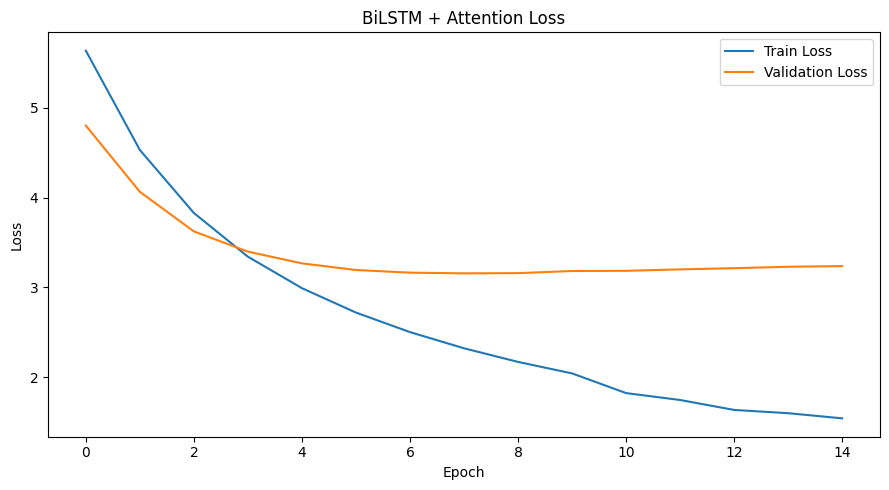

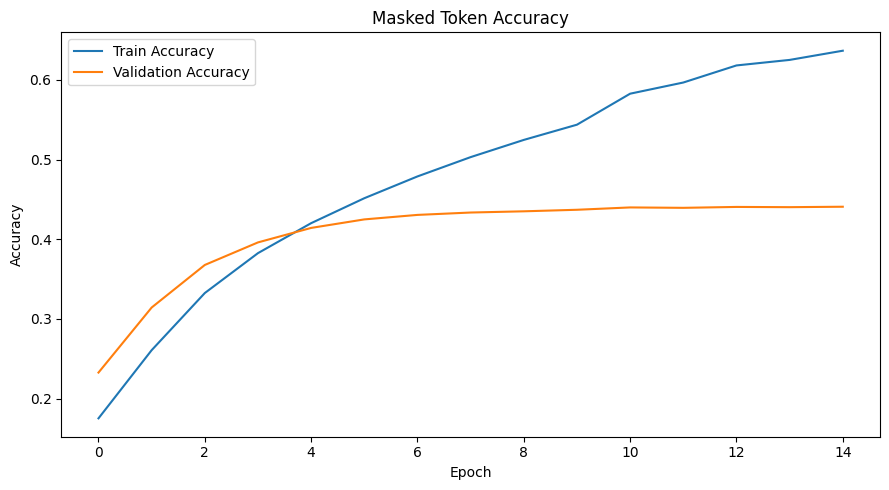

In [11]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(9, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("BiLSTM + Attention Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "loss_curve.png"), dpi=160)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["masked_accuracy"], label="Train Accuracy")
plt.plot(history_df["val_masked_accuracy"], label="Validation Accuracy")
plt.title("Masked Token Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "accuracy_curve.png"), dpi=160)
plt.show()


## 10. Test-set evaluation

In [12]:
if os.path.exists(best_weights_path):
    training_model.load_weights(best_weights_path)
    print("Loaded best checkpoint:", best_weights_path)

test_results = training_model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

print("Test results:")
for k, v in test_results.items():
    print(f"{k}: {v:.4f}")


Loaded best checkpoint: models/best_bilstm_attention.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - loss: 3.1557 - masked_accuracy: 0.4325
Test results:
loss: 3.1557
masked_accuracy: 0.4325


## 11. Build inference models

The decoder is executed one token at a time during inference. The encoder returns the full sequence so that the attention layer can align generated French tokens with English source tokens.

In [13]:
# ============================================================
# 9. Build inference models
# ============================================================

encoder_model = tf.keras.Model(
    source_input,
    [enc_outputs, dec_init_h, dec_init_c],
    name="encoder_inference"
)

step_token = tf.keras.Input(
    shape=(1,), dtype=tf.int32, name="step_token"
)

step_h = tf.keras.Input(
    shape=(DECODER_UNITS,), dtype=tf.float32, name="step_h"
)

step_c = tf.keras.Input(
    shape=(DECODER_UNITS,), dtype=tf.float32, name="step_c"
)

step_encoder_outputs = tf.keras.Input(
    shape=(MAX_LEN, ENCODER_UNITS * 2),
    dtype=tf.float32,
    name="step_encoder_outputs"
)

step_encoder_mask = tf.keras.Input(
    shape=(MAX_LEN,),
    dtype=tf.bool,
    name="step_encoder_mask"
)

step_emb = decoder_embedding(step_token)

step_dec_output, next_h, next_c = decoder_lstm(
    step_emb,
    initial_state=[step_h, step_c]
)

step_context, step_attention_scores = attention_layer(
    [step_dec_output, step_encoder_outputs],
    encoder_padding_mask=step_encoder_mask
)

step_combined = tf.keras.layers.Concatenate(axis=-1)(
    [step_dec_output, step_context]
)

step_combined = attention_dropout(step_combined, training=False)
step_probs = decoder_dense(step_combined)

decoder_model = tf.keras.Model(
    [
        step_token,
        step_h,
        step_c,
        step_encoder_outputs,
        step_encoder_mask
    ],
    [
        step_probs,
        next_h,
        next_c,
        step_attention_scores
    ],
    name="decoder_inference"
)

print("Inference models built successfully.")
print("step_probs:", decoder_model.output_shape[0])
print("attention:", decoder_model.output_shape[3])

Inference models built successfully.
step_probs: (None, 1, 20000)
attention: (None, 1, 40)


## 12. Improved inference

This cell supports:
- greedy decoding (`temperature=0`)
- temperature sampling (`temperature > 0`)
- repeated-token penalty
- early stopping at `[end]`

In [14]:
def sample_from_logits(logits, temperature=1.0, repetition_penalty=1.0, generated_ids=None):
    logits = np.asarray(logits, dtype=np.float64).copy()

    if generated_ids and repetition_penalty != 1.0:
        for token_id in set(generated_ids):
            if token_id == 0:
                continue
            if logits[token_id] > 0:
                logits[token_id] /= repetition_penalty
            else:
                logits[token_id] *= repetition_penalty

    if temperature <= 0:
        return int(np.argmax(logits))

    logits = logits / temperature
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    probs = probs / np.sum(probs)

    return int(np.random.choice(len(probs), p=probs))


def translate_sentence(
    sentence,
    max_target_len=MAX_LEN,
    temperature=0.0,
    repetition_penalty=1.0,
    return_attention=False
):
    source_tokens = source_vectorizer(
        tf.constant([clean_text(sentence)])
    )

    enc_out, h, c = encoder_model.predict(
        source_tokens,
        verbose=0
    )
    source_mask = (source_tokens.numpy() != 0)

    current_token = np.array([[START_ID]], dtype=np.int32)
    generated_ids = []
    attention_history = []

    for _ in range(max_target_len):
        probs, h, c, scores = decoder_model.predict(
            [current_token, h, c, enc_out, source_mask],
            verbose=0
        )

        logits = np.log(np.clip(probs[0, -1, :], 1e-9, 1.0))

        # Never generate padding/start as normal output.
        logits[0] = -1e9
        if START_ID is not None:
            logits[START_ID] = -1e9

        next_id = sample_from_logits(
            logits,
            temperature=temperature,
            repetition_penalty=repetition_penalty,
            generated_ids=generated_ids
        )

        if next_id == END_ID:
            break

        word = target_id_to_word.get(next_id, "[UNK]")

        if word not in {"", "[UNK]", "[start]"}:
            generated_ids.append(next_id)

        attention_history.append(scores[0, 0, :])
        current_token = np.array([[next_id]], dtype=np.int32)

    words = [
        target_id_to_word.get(i, "[UNK]")
        for i in generated_ids
        if target_id_to_word.get(i, "[UNK]") not in {"[start]", "[end]", ""}
    ]

    result = " ".join(words)

    if return_attention:
        attn = np.array(attention_history)
        return result, attn

    return result


examples = [
    "i love this book",
    "the weather is beautiful",
    "we are going to the city",
    "this is a very important question"
]

for sentence in examples:
    print("EN:", sentence)
    print("FR:", translate_sentence(sentence, temperature=0.0))
    print("-" * 80)


EN: i love this book
FR: je t'aime ce livre !
--------------------------------------------------------------------------------
EN: the weather is beautiful
FR: le temps est beau :
--------------------------------------------------------------------------------
EN: we are going to the city
FR: nous allons visiter la ville.
--------------------------------------------------------------------------------
EN: this is a very important question
FR: c est une question de
--------------------------------------------------------------------------------


## 13. BLEU score on the test set

BLEU is calculated from generated translations against the reference French sentences.

For speed, the default evaluates 2,000 test examples. Set `BLEU_EVAL_SIZE = None` to evaluate the entire test set.

In [ ]:
BLEU_EVAL_SIZE = min(2000, len(test_pairs))

bleu_subset = test_pairs.sample(
    n=BLEU_EVAL_SIZE,
    random_state=SEED
).reset_index(drop=True)

references = []
hypotheses = []

smooth = SmoothingFunction().method1

for i, row in bleu_subset.iterrows():
    pred = translate_sentence(
        row["en"],
        temperature=0.0
    )

    ref_tokens = row["fr"].split()
    pred_tokens = pred.split()

    references.append([ref_tokens])
    hypotheses.append(pred_tokens)

bleu_score = corpus_bleu(
    references,
    hypotheses,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smooth
)

print(f"BLEU-4 on {BLEU_EVAL_SIZE:,} test examples: {bleu_score:.4f}")
print(f"BLEU-4 percentage: {bleu_score * 100:.2f}")

## 14. Token-level confusion matrix

A full 20k × 20k confusion matrix is not useful visually. We therefore select the most frequent non-padding target tokens and build a compact token-level confusion matrix from teacher-forced test predictions.

This is a diagnostic visualization, **not a sentence-level translation metric**.

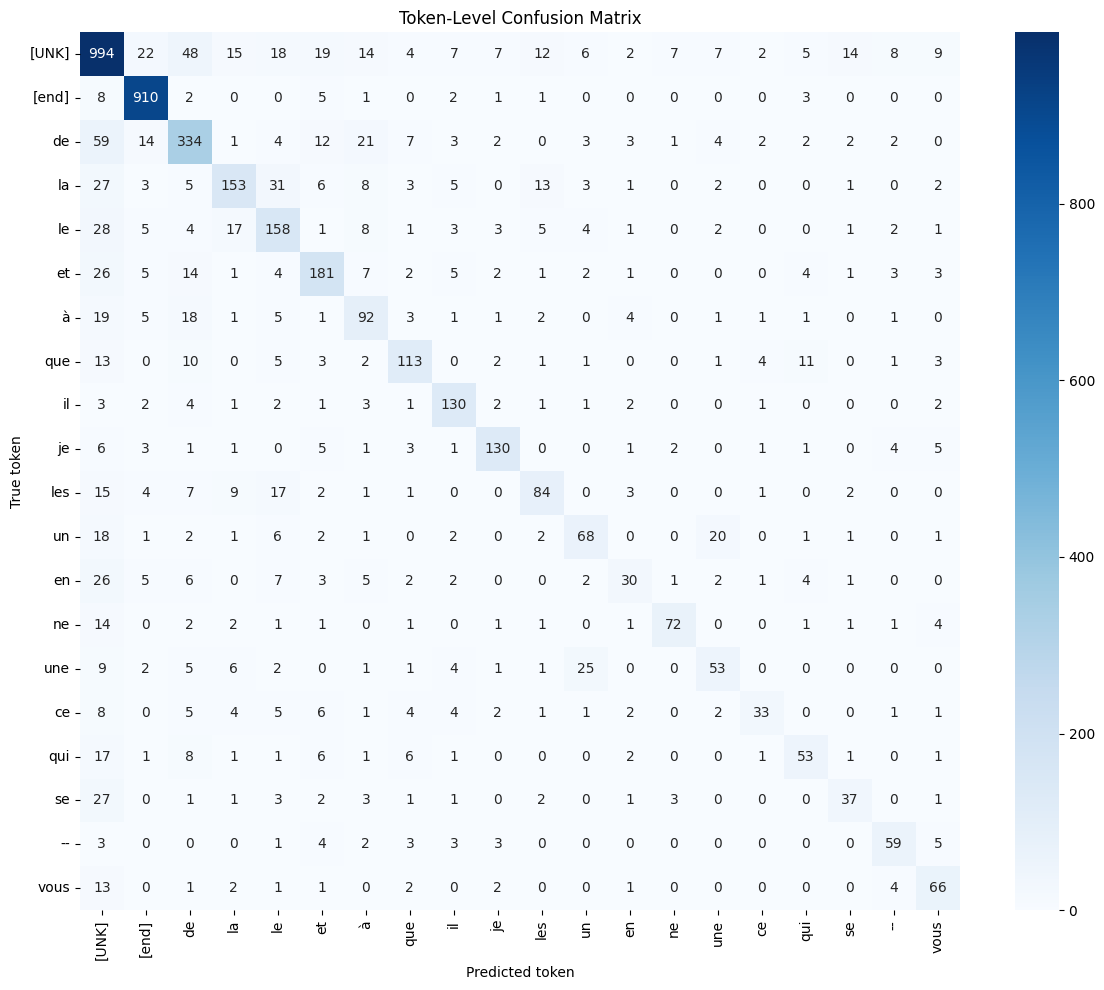

In [16]:
CONFUSION_TOP_K = 20
CONFUSION_BATCHES = 30

true_tokens = []
pred_tokens = []

for batch_idx, (x_batch, y_batch) in enumerate(test_ds.take(CONFUSION_BATCHES)):
    probs = training_model.predict(x_batch, verbose=0)
    pred_ids = np.argmax(probs, axis=-1)

    y_np = y_batch.numpy().reshape(-1)
    p_np = pred_ids.reshape(-1)

    mask = y_np != 0

    true_tokens.extend(y_np[mask].tolist())
    pred_tokens.extend(p_np[mask].tolist())

freq = pd.Series(true_tokens).value_counts()
selected_ids = freq.head(CONFUSION_TOP_K).index.tolist()

# Add the most frequent predicted IDs if useful.
for pid in pd.Series(pred_tokens).value_counts().index.tolist():
    if pid not in selected_ids:
        selected_ids.append(int(pid))
    if len(selected_ids) >= CONFUSION_TOP_K:
        break

labels = [
    target_id_to_word.get(int(i), "[UNK]")
    for i in selected_ids
]

mask_selected = [
    (t in selected_ids) and (p in selected_ids)
    for t, p in zip(true_tokens, pred_tokens)
]

y_true_cm = [t for t, keep in zip(true_tokens, mask_selected) if keep]
y_pred_cm = [p for p, keep in zip(pred_tokens, mask_selected) if keep]

cm = confusion_matrix(
    y_true_cm,
    y_pred_cm,
    labels=selected_ids
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Token-Level Confusion Matrix")
plt.xlabel("Predicted token")
plt.ylabel("True token")
plt.tight_layout()
plt.savefig(
    os.path.join(VIS_DIR, "token_confusion_matrix.png"),
    dpi=180
)
plt.show()

## 15. Attention heatmap

The heatmap shows which English source positions receive the highest attention while generating each French output token.


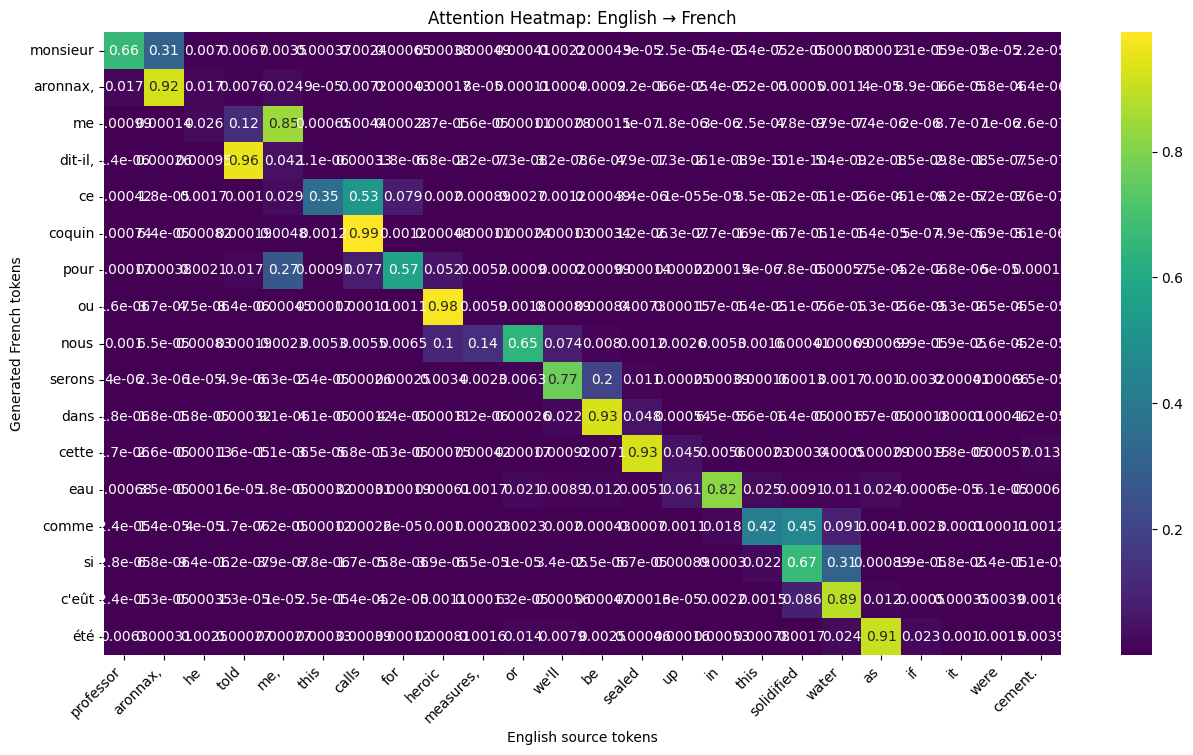

English: professor aronnax, he told me, this calls for heroic measures, or we'll be sealed up in this solidified water as if it were cement.
French : monsieur aronnax, me dit-il, ce coquin pour ou nous serons dans cette eau comme si c'eût été


In [17]:
def tokenize_for_attention(sentence):
    return clean_text(sentence).split()[:MAX_LEN]

attention_sentence = test_pairs.iloc[0]["en"]

prediction, attention_matrix = translate_sentence(
    attention_sentence,
    temperature=0.0,
    return_attention=True
)

source_words = tokenize_for_attention(attention_sentence)
target_words = prediction.split()

# Attention matrix shape is approximately:
# generated_target_length × MAX_LEN
attn = attention_matrix[:len(target_words), :len(source_words)]

# Normalize each target-token row for easier visualization.
if attn.size:
    row_sums = attn.sum(axis=1, keepdims=True) + 1e-8
    attn = attn / row_sums

plt.figure(figsize=(max(10, len(source_words) * 0.55), max(5, len(target_words) * 0.45)))
sns.heatmap(
    attn,
    cmap="viridis",
    xticklabels=source_words,
    yticklabels=target_words,
    cbar=True,
    annot=True
)
plt.title("Attention Heatmap: English → French")
plt.xlabel("English source tokens")
plt.ylabel("Generated French tokens")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    os.path.join(VIS_DIR, "attention_heatmap.png"),
    dpi=180,
    bbox_inches="tight"
)
plt.show()

print("English:", attention_sentence)
print("French :", prediction)


## 16. Qualitative translation comparison

In [18]:
sample_test = test_pairs.sample(
    n=min(15, len(test_pairs)),
    random_state=SEED
)

for _, row in sample_test.iterrows():
    prediction = translate_sentence(
        row["en"],
        temperature=0.0
    )

    print("EN  :", row["en"])
    print("REF :", row["fr"])
    print("PRED:", prediction)
    print("-" * 110)


EN  : she dreamed of high station; she already saw him, tall, handsome, clever, settled as an engineer or in the law.
REF : elle rêvait de hautes positions, elle le voyait déjà grand, beau, spirituel, établi, dans les ponts et chaussées ou dans la magistrature.
PRED: elle songeait à haute elle le voyait très grand, et comme un
--------------------------------------------------------------------------------------------------------------
EN  : all three felt this, and they well knew that cyrus harding would approve of their acting thus.
REF : tous trois le comprirent, et ils savaient bien que cyrus smith les approuverait d'avoir agi ainsi.
PRED: tous trois sentirent et ils savaient que cyrus smith de leur goût.
--------------------------------------------------------------------------------------------------------------
EN  : charles went up the first floor to see the patient.
REF : charles monta, au premier, voir le malade.
PRED: charles descendit le premier pour voir le
---------------

## 17. Optional temperature-based inference

For deterministic evaluation, keep `temperature=0.0`.

A small temperature such as `0.7` can produce alternative outputs, but sampled output should **not** be used for the main BLEU benchmark.

In [19]:
sentence = "we are going to the city"

print("Input:", sentence)
print("Greedy:", translate_sentence(sentence, temperature=0.0))
print("Sample:", translate_sentence(sentence, temperature=0.7, repetition_penalty=1.15))


Input: we are going to the city
Greedy: nous allons visiter la ville.
Sample: nous allons visiter la ville à la ville.


## 18. Save model weights, vocabularies, and configuration

In [20]:
final_weights_path = os.path.join(
    MODEL_DIR,
    "seq2seq_bilstm_attention.weights.h5"
)

training_model.save_weights(final_weights_path)

config = {
    "MAX_SAMPLES": MAX_SAMPLES,
    "MAX_LEN": MAX_LEN,
    "VOCAB_SIZE": VOCAB_SIZE,
    "EMBED_DIM": EMBED_DIM,
    "ENCODER_UNITS": ENCODER_UNITS,
    "DECODER_UNITS": DECODER_UNITS,
    "DROPOUT_RATE": DROPOUT_RATE,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "WEIGHT_DECAY": 1e-4,
    "CLIPNORM": 1.0,
    "source_vocab_size": source_vocab_size,
    "target_vocab_size": target_vocab_size,
    "START_ID": int(START_ID),
    "END_ID": int(END_ID),
    "test_bleu": float(bleu_score)
}

with open(os.path.join(MODEL_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

with open(os.path.join(MODEL_DIR, "source_vocab.json"), "w", encoding="utf-8") as f:
    json.dump(source_vocab, f, ensure_ascii=False)

with open(os.path.join(MODEL_DIR, "target_vocab.json"), "w", encoding="utf-8") as f:
    json.dump(target_vocab, f, ensure_ascii=False)

print("Saved:", final_weights_path)
print("Saved:", os.path.join(MODEL_DIR, "config.json"))
print("Saved vocabularies.")


Saved: models/seq2seq_bilstm_attention.weights.h5
Saved: models/config.json
Saved vocabularies.
